In [1]:
import polars as pl
import numpy as np

In [3]:
# Load the training data
train_df = pl.read_csv("data/train.csv")

# Display the first few rows
print("Training data head:")
train_df.head()

Training data head:


id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
i64,str,i64,f64,f64,f64,f64,f64,f64
0,"""male""",36,189.0,82.0,26.0,101.0,41.0,150.0
1,"""female""",64,163.0,60.0,8.0,85.0,39.7,34.0
2,"""female""",51,161.0,64.0,7.0,84.0,39.8,29.0
3,"""male""",20,192.0,90.0,25.0,105.0,40.7,140.0
4,"""female""",38,166.0,61.0,25.0,102.0,40.6,146.0


In [4]:
train_df.shape, train_df.dtypes  

((750000, 9),
 [Int64, String, Int64, Float64, Float64, Float64, Float64, Float64, Float64])

In [5]:
numeric_cols = [
    "Height",
    "Weight",
    "Duration",
    "Heart_Rate",
    "Body_Temp",
]

train_df.select(numeric_cols).describe()

statistic,Height,Weight,Duration,Heart_Rate,Body_Temp
str,f64,f64,f64,f64,f64
"""count""",750000.0,750000.0,750000.0,750000.0,750000.0
"""null_count""",0.0,0.0,0.0,0.0,0.0
"""mean""",174.697685,75.145668,15.421015,95.483995,40.036253
"""std""",12.824496,13.982704,8.354095,9.449845,0.779875
"""min""",126.0,36.0,1.0,67.0,37.1
"""25%""",164.0,63.0,8.0,88.0,39.6
"""50%""",174.0,74.0,15.0,95.0,40.3
"""75%""",185.0,87.0,23.0,103.0,40.7
"""max""",222.0,132.0,30.0,128.0,41.5


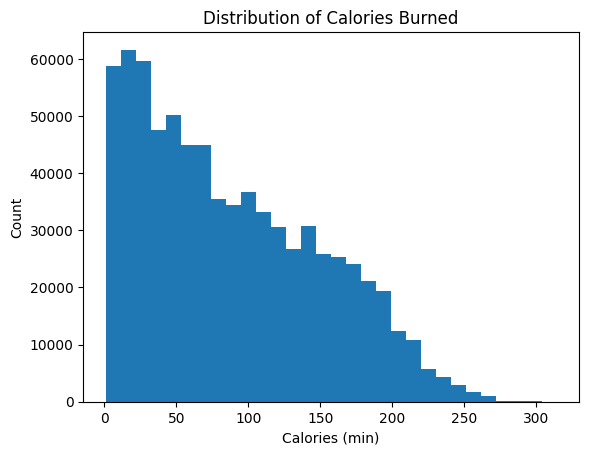

In [6]:
import matplotlib.pyplot as plt

arr = train_df["Calories"].drop_nulls().to_numpy()
plt.hist(arr, bins=30)
plt.xlabel("Calories (min)")
plt.ylabel("Count")
plt.title("Distribution of Calories Burned")
plt.show()

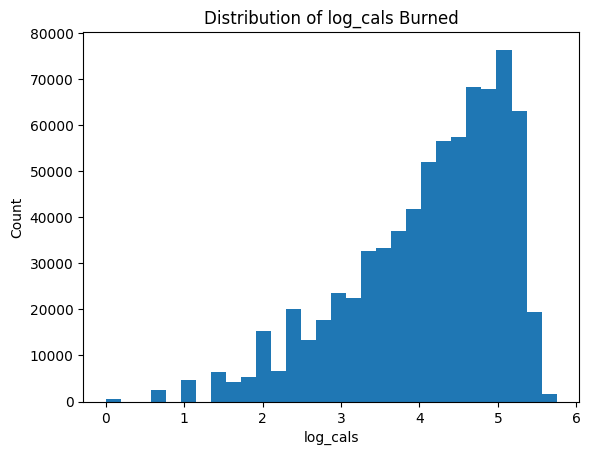

In [10]:
train_df = train_df.with_columns(pl.col("Calories").log().alias("log_cals"))
arr = train_df["log_cals"].drop_nulls().to_numpy()
plt.hist(arr, bins=30)
plt.xlabel("log_cals")
plt.ylabel("Count")
plt.title("Distribution of log_cals Burned")
plt.show()